In [147]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
!pip install pandas-datareader yfinance tensorflow keras
import pandas_datareader as data

plt.style.use('fivethirtyeight')
%matplotlib inline

In [148]:
import yfinance as yf
import datetime as dt

stock = "POWERGRID.NS"
start = dt.datetime(2000, 1, 1)
end = dt.datetime(2025, 12, 1)

df = yf.download(stock, start, end)

/tmp/ipykernel_2465/3706122649.py:8: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed


In [149]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS
Date,,,,,
2007-10-05,30.896235,33.629600,25.536997,27.579343,855215656
2007-10-08,29.314571,31.940444,29.130299,31.940444,126671715
2007-10-09,31.310852,31.587259,27.748264,29.329929,116725709
2007-10-10,31.602621,32.247573,31.326214,32.124724,67931378
2007-10-11,35.134483,36.854354,31.326202,36.854354,106320954


In [150]:
df.shape

(4475, 5)

In [151]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4475 entries, 2007-10-05 to 2025-11-28
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   (Close, POWERGRID.NS)   4475 non-null   float64
 1   (High, POWERGRID.NS)    4475 non-null   float64
 2   (Low, POWERGRID.NS)     4475 non-null   float64
 3   (Open, POWERGRID.NS)    4475 non-null   float64
 4   (Volume, POWERGRID.NS)  4475 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 209.8 KB


In [152]:
df.isnull().sum()

,,0
Price,Ticker,
Close,POWERGRID.NS,0
High,POWERGRID.NS,0
Low,POWERGRID.NS,0
Open,POWERGRID.NS,0
Volume,POWERGRID.NS,0


In [153]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS
count,4475.000000,4475.000000,4475.000000,4475.000000,4.475000e+03
mean,88.466382,89.585244,87.371326,88.512991,1.193918e+07
std,77.572155,78.442210,76.696103,77.587376,2.005620e+07
min,18.038855,19.282913,16.172767,19.189608,0.000000e+00
25%,35.074217,35.651567,34.640441,35.146422,4.952255e+06
50%,64.275146,65.199453,63.442502,64.310681,8.580196e+06
75%,99.113800,100.432698,97.692662,99.188895,1.381374e+07
max,344.843201,345.598137,337.058398,343.522120,8.552157e+08


In [154]:
df=df.reset_index()

In [155]:
df

Price,Date,Close,High,Low,Open,Volume
Ticker,,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS
0,2007-10-05,30.896235,33.629600,25.536997,27.579343,855215656
1,2007-10-08,29.314571,31.940444,29.130299,31.940444,126671715
2,2007-10-09,31.310852,31.587259,27.748264,29.329929,116725709
3,2007-10-10,31.602621,32.247573,31.326214,32.124724,67931378
4,2007-10-11,35.134483,36.854354,31.326202,36.854354,106320954
...,...,...,...,...,...,...
4470,2025-11-24,272.738159,275.952079,269.474807,274.913748,49791096
4471,2025-11-25,270.414276,273.825957,269.623139,271.947057,12114606
4472,2025-11-26,271.996490,273.875422,270.463710,270.958159,8352869


In [156]:
df.columns

MultiIndex([(  'Date',             ''),
            ( 'Close', 'POWERGRID.NS'),
            (  'High', 'POWERGRID.NS'),
            (   'Low', 'POWERGRID.NS'),
            (  'Open', 'POWERGRID.NS'),
            ('Volume', 'POWERGRID.NS')],
           names=['Price', 'Ticker'])

In [157]:
df.to_csv("powergrid.csv")

In [158]:
data = pd.read_csv("powergrid.csv")

In [159]:
data

,Price,Date,Close,High,Low,Open,Volume
0,Ticker,NaN,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS
1,0,2007-10-05,30.8962345123291,33.629599819005456,25.536996577029846,27.57934288053112,855215656
2,1,2007-10-08,29.314571380615234,31.940444166313526,29.130298802297208,31.940444166313526,126671715
3,2,2007-10-09,31.31085205078125,31.587258865753952,27.748263753421156,29.329928906587007,116725709
4,3,2007-10-10,31.60262107849121,32.24757320916687,31.326214212652225,32.1247240932918,67931378
...,...,...,...,...,...,...,...
4471,4470,2025-11-24,272.7381591796875,275.9520788916759,269.4748066205665,274.91374767162375,49791096
4472,4471,2025-11-25,270.4142761230469,273.8259574525211,269.62313930580683,271.94705655209975,12114606
4473,4472,2025-11-26,271.9964904785156,273.8754215651714,270.46371004338476,270.9581592390765,8352869
4474,4473,2025-11-27,270.6614990234375,273.9248516100949,270.26591552790507,273.9248516100949,9865039


In [160]:
# Candlesticks
import plotly.graph_objects as go

fig = go.Figure(data=[go.Candlestick(x = data['Date'], open = data['Open'],
                                    high = data['High'],
                                    low = data['Low'],
                                    close = data['Close'])])
fig.update_layout(xaxis_rangeslider_visible=False)
fig.show()

In [161]:
df = df.drop(['Date'], axis = 1)

/tmp/ipykernel_2465/1002300862.py:1: PerformanceWarning:

dropping on a non-lexsorted multi-index without a level parameter may impact performance.



In [162]:
df

Price,Close,High,Low,Open,Volume
Ticker,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS
0,30.896235,33.629600,25.536997,27.579343,855215656
1,29.314571,31.940444,29.130299,31.940444,126671715
2,31.310852,31.587259,27.748264,29.329929,116725709
3,31.602621,32.247573,31.326214,32.124724,67931378
4,35.134483,36.854354,31.326202,36.854354,106320954
...,...,...,...,...,...
4470,272.738159,275.952079,269.474807,274.913748,49791096
4471,270.414276,273.825957,269.623139,271.947057,12114606
4472,271.996490,273.875422,270.463710,270.958159,8352869


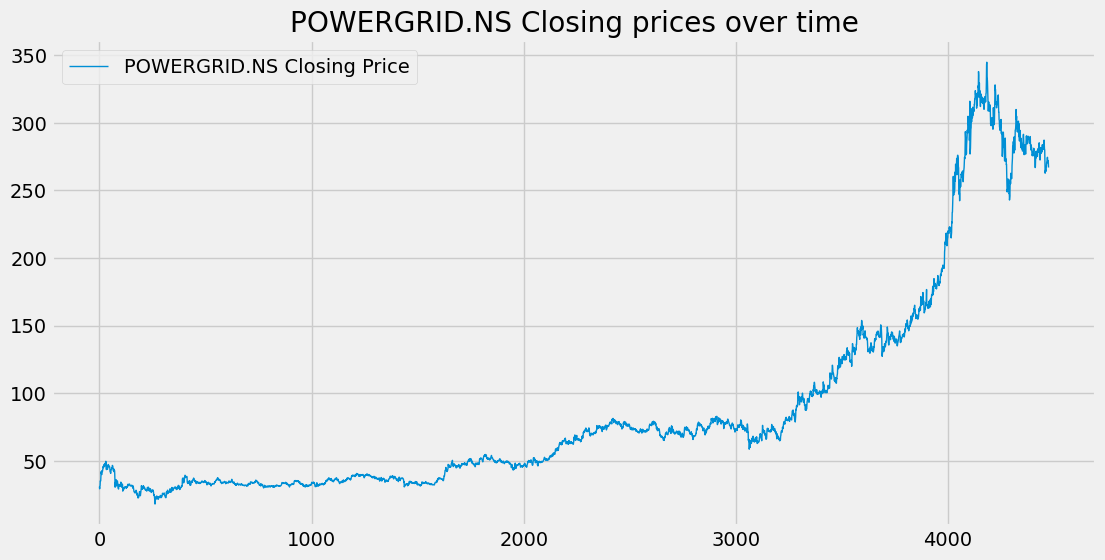

In [163]:
plt.figure(figsize=(12, 6))
plt.plot(df['Close'], label = f'{stock} Closing Price', linewidth = 1)
plt.title(f'{stock} Closing prices over time')
plt.legend()
plt.show()

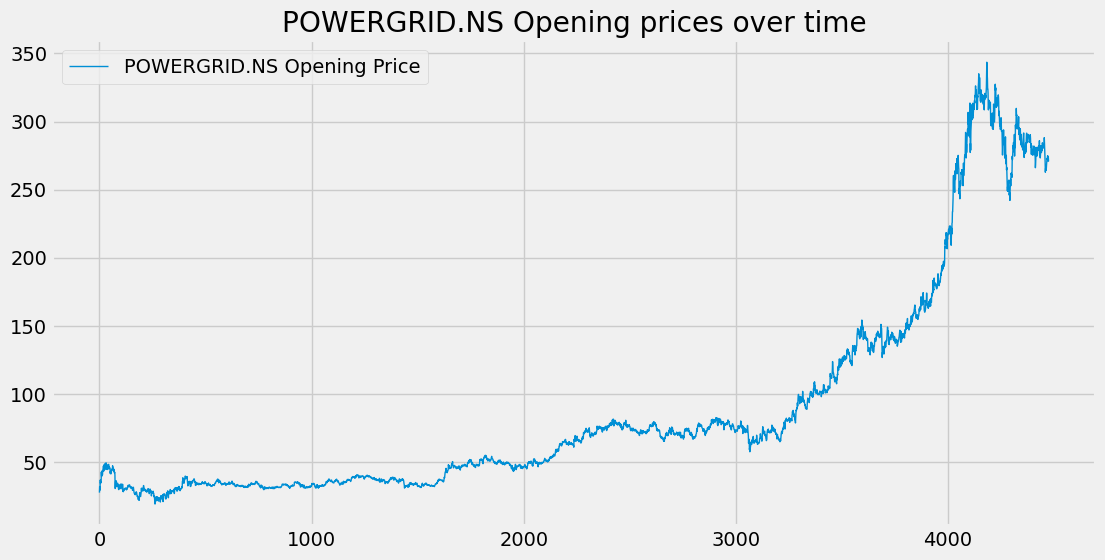

In [164]:
plt.figure(figsize=(12, 6))
plt.plot(df['Open'], label = f'{stock} Opening Price', linewidth = 1)
plt.title(f'{stock} Opening prices over time')
plt.legend()
plt.show()

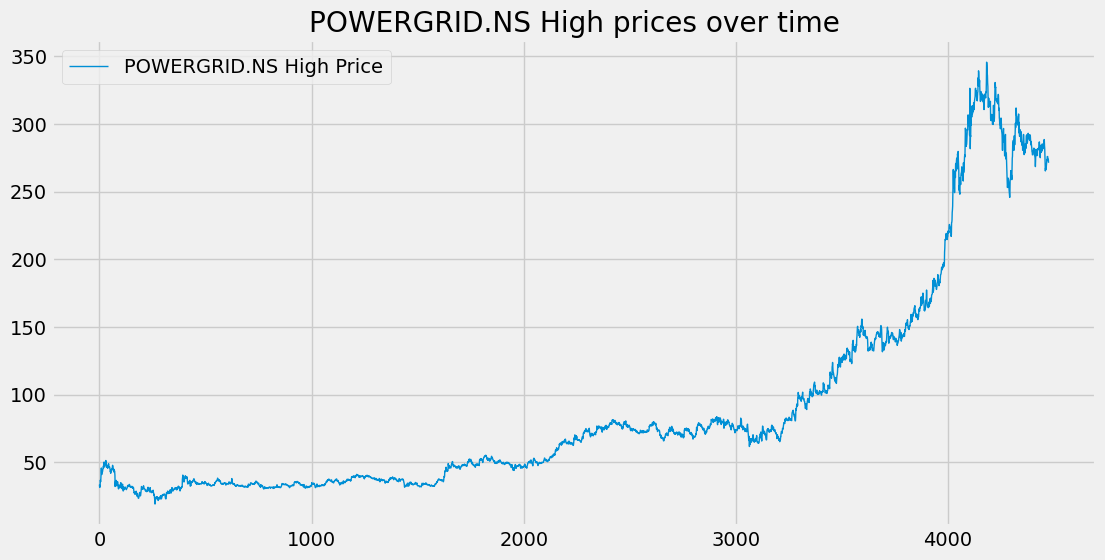

In [165]:
plt.figure(figsize=(12, 6))
plt.plot(df['High'], label = f'{stock} High Price', linewidth = 1)
plt.title(f'{stock} High prices over time')
plt.legend()
plt.show()

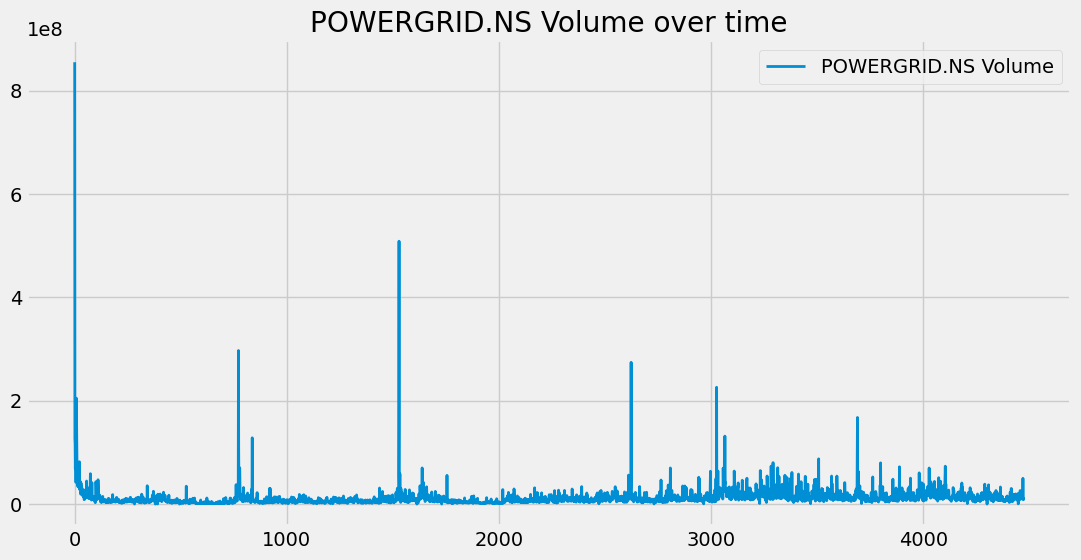

In [166]:
plt.figure(figsize=(12, 6))
plt.plot(df['Volume'], label = f'{stock} Volume', linewidth = 2)
plt.title(f'{stock} Volume over time')
plt.legend()
plt.show()

In [167]:
# Moving Average
# [10, 20, 30, 40, 50, 60, 70, 80, 90]
# moving average for last 5 days -> null null null null 30.0 40.0 50.0

temp_data = [10, 20, 30, 40, 50, 60, 70, 80, 90]
print(sum(temp_data[2:7])/5)

50.0


In [168]:
df01 = pd.DataFrame(temp_data)

In [169]:
df01.rolling(5).mean()

,0
0,NaN
1,NaN
2,NaN
3,NaN
4,30.0
5,40.0
6,50.0
7,60.0
8,70.0


In [170]:
ma100 = df.Close.rolling(100).mean()

In [171]:
ma100

Ticker,POWERGRID.NS
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
4470,278.864908
4471,278.687722
4472,278.552503
4473,278.415071


In [172]:
ma200 = df.Close.rolling(200).mean()

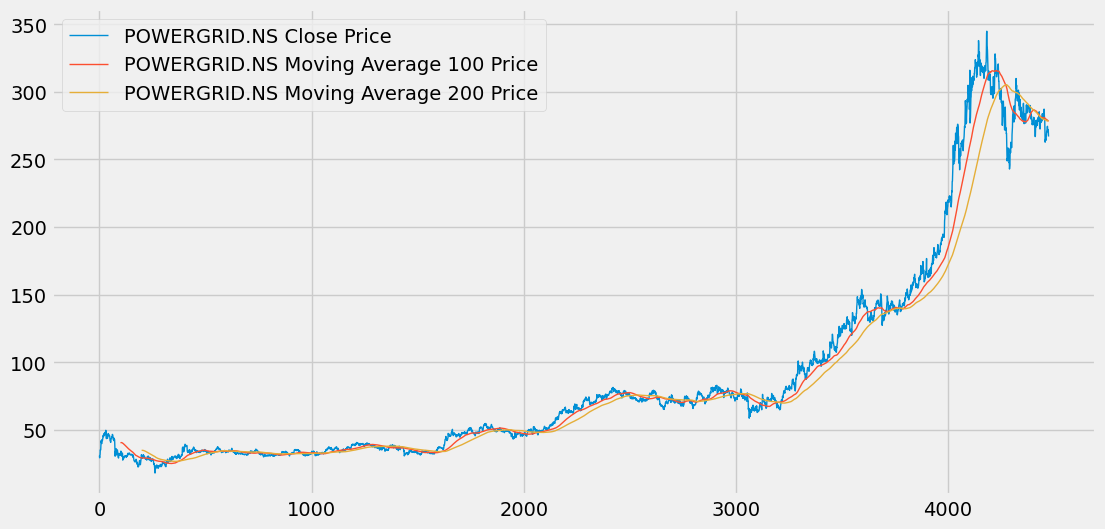

In [173]:
plt.figure(figsize=(12, 6))
plt.plot(df.Close, label = f'{stock} Close Price', linewidth = 1)
plt.plot(ma100, label = f'{stock} Moving Average 100 Price', linewidth = 1)
plt.plot(ma200, label = f'{stock} Moving Average 200 Price', linewidth = 1)
plt.legend()
plt.show()

In [174]:
ema100 = df.Close.ewm(span=100, adjust = False).mean()

In [175]:
ema200 = df['Close'].ewm(span=200, adjust = False).mean()

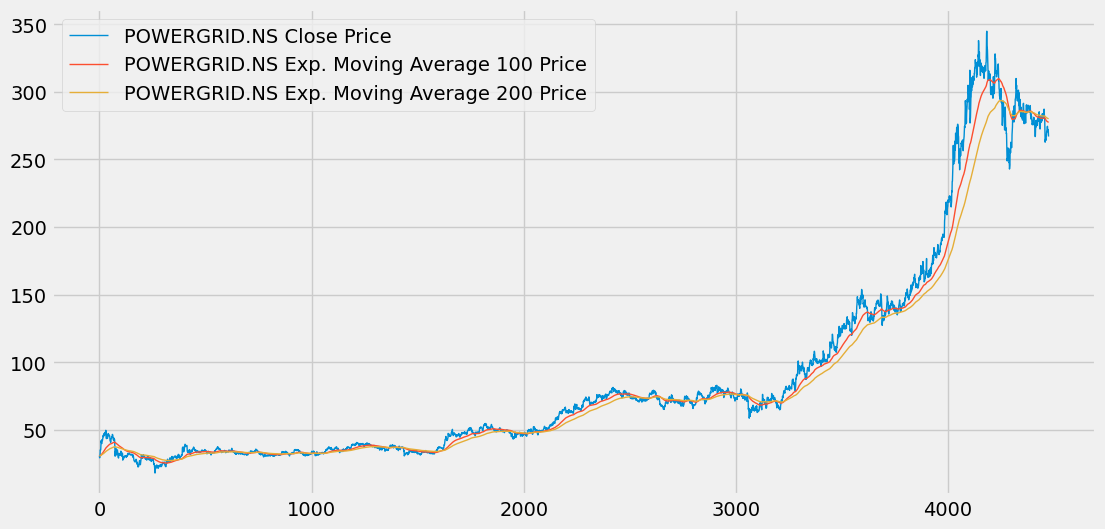

In [176]:
plt.figure(figsize=(12, 6))
plt.plot(df.Close, label = f'{stock} Close Price', linewidth = 1)
plt.plot(ema100, label = f'{stock} Exp. Moving Average 100 Price', linewidth = 1)
plt.plot(ema200, label = f'{stock} Exp. Moving Average 200 Price', linewidth = 1)
plt.legend()
plt.show()

In [177]:
# Training & Testing

data_training = pd.DataFrame(df['Close'][0:int(len(df)*0.70)])
data_testing = pd.DataFrame(df['Close'][int(len(df)*0.70): int(len(df))])

In [178]:
data_training.shape

(3132, 1)

In [179]:
data_testing.shape

(1343, 1)

In [180]:
from sklearn.preprocessing import MinMaxScaler
scaler= MinMaxScaler(feature_range=(0,1))

In [181]:
data_training_array = scaler.fit_transform(data_training)

In [182]:
data_training_array

array([[0.19808598],
       [0.17371824],
       [0.20447375],
       ...,
       [0.84486728],
       [0.83891486],
       [0.8176121 ]])

In [183]:
data_training_array.shape[0]

3132

In [184]:
x_train = []
y_train = []

for i in range(100, data_training_array.shape[0]):
    x_train.append(data_training_array[i-100:i])
    y_train.append(data_training_array[i, 0])

x_train, y_train  = np.array(x_train), np.array(y_train)

In [185]:
x_train.shape

(3032, 100, 1)

In [186]:
# Model Building
from keras.layers import Dense, Dropout, LSTM
from keras.models import Sequential

In [187]:
model = Sequential()

model.add(LSTM(units = 50, activation = 'relu', return_sequences = True, input_shape = (x_train.shape[1],1)))
model.add(Dropout(0.2))

model.add(LSTM(units = 60, activation = 'relu', return_sequences = True))
model.add(Dropout(0.3))

model.add(LSTM(units = 80, activation = 'relu', return_sequences = True))
model.add(Dropout(0.4))

model.add(LSTM(units = 120, activation = 'relu'))
model.add(Dropout(0.5))

model.add(Dense(units = 1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



In [188]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 100, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 100, 60)        │        26,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 100, 60)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 100, 80)        │        45,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 100, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 120)            │        96,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           121 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 178,761 (698.29 KB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)

In [189]:
model.compile(optimizer = 'adam', loss = 'mean_squared_error')
model.fit(x_train, y_train, epochs = 50)

Epoch 1/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 39s 338ms/step - loss: 0.0323
Epoch 2/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 34s 265ms/step - loss: 0.0095
Epoch 3/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 42s 272ms/step - loss: 0.0077
Epoch 4/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 29s 305ms/step - loss: 0.0071
Epoch 5/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 37s 268ms/step - loss: 0.0066
Epoch 6/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 41s 265ms/step - loss: 0.0062
Epoch 7/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 42s 275ms/step - loss: 0.0057
Epoch 8/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 25s 262ms/step - loss: 0.0055
Epoch 9/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 25s 262ms/step - loss: 0.0056
Epoch 10/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 42s 274ms/step - loss: 0.0051
Epoch 11/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 40s 268ms/step - loss: 0.0047
Epoch 12/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 41s 262ms/step - loss: 0.0045
Epoch 13/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 25s 260ms/step - loss: 0.0043
Epoch 14/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 42s 269ms/step - loss: 0.0040
Epoch 15/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 25s 

In [190]:
past_100_days = data_training.tail(100)

In [191]:
final_df = pd.concat([past_100_days, data_testing], ignore_index=True)

In [201]:
input_data = scaler.transform(final_df)

In [202]:
x_test = []
y_test = []

for i in range(100, input_data.shape[0]):
    x_test.append(input_data[i-100:i])
    y_test.append(input_data[i, 0])

x_test, y_test  = np.array(x_test), np.array(y_test)

In [203]:
x_test.shape

(1343, 100, 1)

In [204]:
y_predicted = model.predict(x_test)

42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step


In [205]:
scaler.scale_

array([0.00349382])

In [206]:
scaler_factor = 1 / 0.00349382
y_predicted = y_predicted*scaler_factor
y_test = y_test*scaler_factor

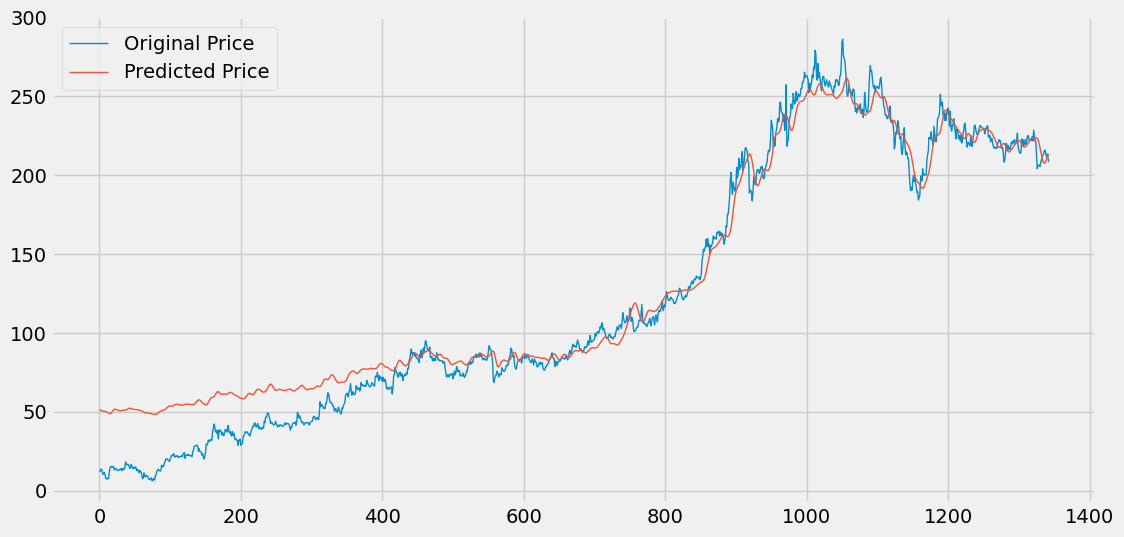

In [207]:
plt.figure(figsize=(12, 6))
plt.plot(y_test, label = 'Original Price', linewidth = 1)
plt.plot(y_predicted, label = 'Predicted Price', linewidth = 1)
plt.legend()
plt.show()

In [217]:
#Evaluating the model
from sklearn.metrics import r2_score
import numpy as np
r2   = r2_score(y_test, y_predicted)
print(f"R²:   {r2:.4f}")

R²:   0.9609


In [218]:
import pandas as pd

sample_df = pd.DataFrame({
    'Actual':    y_test_rescaled[1205:1215].flatten(),
    'Predicted': y_predicted_rescaled[1205:1215].flatten()
})
sample_df['Difference'] = abs(sample_df['Actual'] - sample_df['Predicted'])
print(sample_df)

         Actual     Predicted   Difference
0  65246.636843  67391.562500  2144.925657
1  66272.137215  67206.320312   934.183098
2  66424.566898  66975.648438   551.081539
3  67491.635826  66721.375000   770.260826
4  65787.089209  66493.164062   706.074854
5  65302.067407  66297.484375   995.416968
6  63846.975796  66119.007812  2272.032016
7  65842.537242  65918.101562    75.564320
8  65454.514560  65709.179688   254.665128
9  64858.605425  65511.972656   653.367231


In [220]:
model.save('stock_dl_model.keras')